# A Four-Step Travel Demand Model for Milan

The classical **four-step model** is the workhorse of transportation planning:

1. **Trip generation** — how many trips does each zone produce and attract?
2. **Trip distribution** — which origins connect to which destinations? (gravity model)
3. **Mode choice** — car or public transport? (binary logit)
4. **Trip assignment** — which streets do the trips load onto? (shortest paths)

This notebook builds the whole chain **from scratch on real, open data**: Milan's actual
major-road network and municipal boundary from OpenStreetMap, a hexagonal zone system, and
land use proxied from OSM residential areas and workplaces. Everything downloads at run
time — no bundled datasets, fully reproducible.

On top of the four steps it includes the analyses practitioners actually run on assigned
networks: **select-link analysis** and **skim-matrix** extraction.

> **Honesty note on parameters.** Trip rates, the gravity deterrence parameter, logit
> coefficients, and control totals are stated assumptions, not values calibrated against
> Milanese surveys or counts — the point here is the machinery. I have applied this same
> workflow to a real metropolitan planning network (~58,000 links with 2030/2040 scenario
> attributes); that dataset is not distributable, hence this open-data rebuild.

## 1. Milan's boundary and major-road network (OpenStreetMap)

We pull the municipal boundary and the drivable network of major roads (motorway → tertiary)
with OSMnx, then keep the largest strongly connected component so every node can reach every
other node. Speeds are assumed per road class — a deliberate, visible assumption.

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox

ox.settings.use_cache = True
CRS_UTM = "EPSG:32632"                      # UTM 32N — Milan

milan = ox.geocode_to_gdf("Milan, Lombardy, Italy")
boundary = milan.geometry.iloc[0]
print(f"boundary area: {milan.to_crs(CRS_UTM).area.iloc[0] / 1e6:.0f} km²")

boundary area: 182 km²


In [2]:
MAJOR = ('["highway"~"motorway|trunk|primary|secondary|tertiary'
         '|motorway_link|trunk_link|primary_link|secondary_link"]')
G_raw = ox.graph_from_polygon(boundary, network_type="drive",
                              custom_filter=MAJOR, retain_all=True)
# largest strongly connected component -> every OD pair is routable
scc = max(nx.strongly_connected_components(G_raw), key=len)
G_osm = G_raw.subgraph(scc).copy()
G_osm = ox.project_graph(G_osm, to_crs=CRS_UTM)
print(f"network: {G_osm.number_of_nodes():,} nodes, {G_osm.number_of_edges():,} edges")

network: 2,963 nodes, 5,187 edges


In [3]:
# assumed free-flow speeds and per-lane-equivalent capacities by road class
SPEED_KMH = {"motorway": 90, "trunk": 70, "primary": 50, "secondary": 40,
             "tertiary": 30, "motorway_link": 60, "trunk_link": 50,
             "primary_link": 40, "secondary_link": 30}
CAPACITY = {"motorway": 4000, "trunk": 3000, "primary": 1600, "secondary": 1200,
            "tertiary": 800, "motorway_link": 1500, "trunk_link": 1200,
            "primary_link": 800, "secondary_link": 600}

def road_class(hwy):
    h = hwy[0] if isinstance(hwy, list) else hwy
    return h if h in SPEED_KMH else "tertiary"

for u, v, k, d in G_osm.edges(keys=True, data=True):
    cls = road_class(d.get("highway", "tertiary"))
    d["cls"] = cls
    d["time_min"] = d["length"] / 1000 / SPEED_KMH[cls] * 60
    d["capacity"] = CAPACITY[cls]

edges_gdf = ox.graph_to_gdfs(G_osm, nodes=False).reset_index()
edges_gdf.groupby("cls").agg(edges=("length", "size"),
                             km=("length", lambda s: s.sum() / 1000)).round(0)

,edges,km
cls,,
motorway,45,29.0
motorway_link,130,33.0
primary,769,132.0
primary_link,91,4.0
secondary,1415,191.0
secondary_link,133,5.0
tertiary,2477,368.0
trunk,57,25.0
trunk_link,70,14.0


## 2. A hexagonal zone system

Traffic analysis zones as a ~1.2 km hex grid clipped to the municipal boundary — the same
zoning approach as my [transit accessibility work](https://github.com/abadeanlou/Accessibility-using-Transit).

In [4]:
from shapely.geometry import Polygon

boundary_utm = gpd.GeoSeries([boundary], crs="EPSG:4326").to_crs(CRS_UTM).iloc[0]
minx, miny, maxx, maxy = boundary_utm.bounds
R = 700.0                                   # hex circumradius (m) -> ~1.2 km across
dx, dy = 1.5 * R, np.sqrt(3) * R

hexes = []
ix = 0
x = minx - R
while x < maxx + R:
    y0 = miny - R - (dy / 2 if ix % 2 else 0)
    y = y0
    while y < maxy + R:
        hexes.append(Polygon([(x + R * np.cos(a), y + R * np.sin(a))
                              for a in np.linspace(0, 2 * np.pi, 7)[:-1]]))
        y += dy
    x += dx
    ix += 1

grid = gpd.GeoDataFrame(geometry=hexes, crs=CRS_UTM)
grid = grid[grid.intersects(boundary_utm)].copy()
grid["geometry"] = grid.geometry.intersection(boundary_utm)
grid = grid[grid.area > 0.15 * (1.5 * np.sqrt(3) * R * R)].reset_index(drop=True)
grid["Z"] = grid.index + 1
print(f"{len(grid)} zones")

163 zones


## 3. Land use from OpenStreetMap

Two proxies, both imperfect and both stated:

- **Population** ∝ area of `landuse=residential` polygons in each zone, scaled to an
  assumed municipal total of **1.4 M residents**.
- **Jobs** ∝ count of workplace-type OSM features (offices, shops, selected amenities,
  industrial land) in each zone, scaled to an assumed **900 k workplaces**.

Swapping these for census tract data would be the first upgrade in a real study.

In [5]:
residential = ox.features_from_polygon(boundary, {"landuse": ["residential"]})
residential = residential[residential.geometry.geom_type.isin(
    ["Polygon", "MultiPolygon"])].to_crs(CRS_UTM)
print(f"{len(residential):,} residential land-use polygons")

res_union = residential.geometry.union_all()
grid["res_area"] = grid.geometry.intersection(res_union).area

989 residential land-use polygons


In [6]:
jobs_feats = ox.features_from_polygon(
    boundary, {"office": True, "shop": True, "industrial": True,
               "amenity": ["school", "university", "hospital", "restaurant",
                           "cafe", "bank", "pharmacy"]})
jobs_pts = jobs_feats.to_crs(CRS_UTM).copy()
jobs_pts["geometry"] = jobs_pts.geometry.centroid
print(f"{len(jobs_pts):,} workplace-type features")

joined = gpd.sjoin(jobs_pts[["geometry"]], grid[["Z", "geometry"]],
                   how="inner", predicate="within")
grid["poi_count"] = grid["Z"].map(joined.groupby("Z").size()).fillna(0)

17,191 workplace-type features


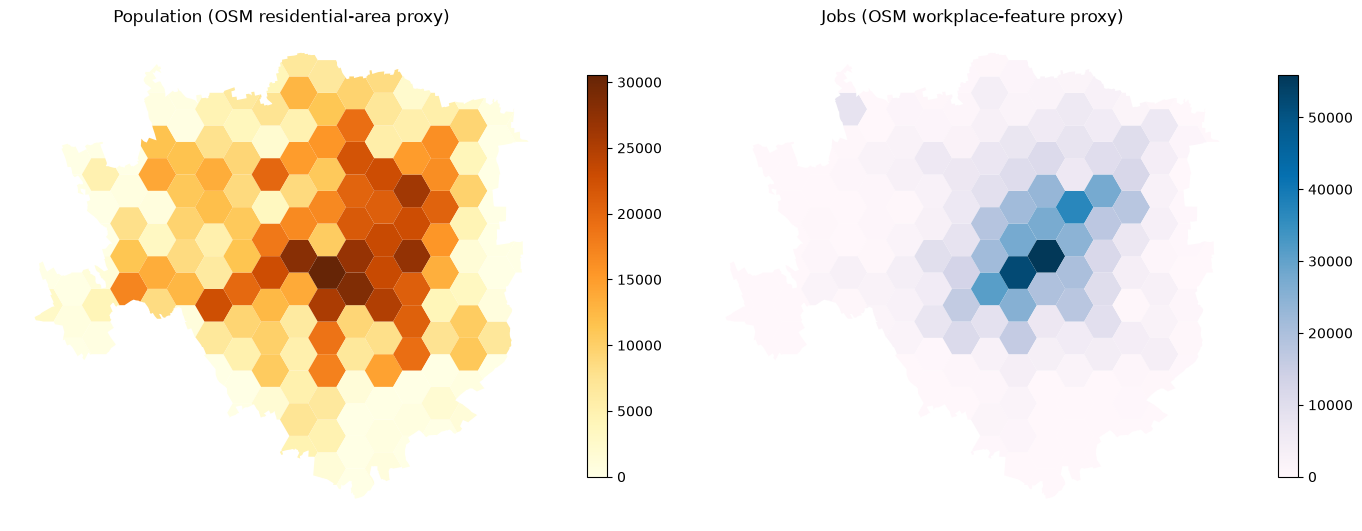

In [7]:
TOTAL_POP, TOTAL_JOBS = 1_400_000, 900_000     # assumed control totals

grid["population"] = grid["res_area"] / grid["res_area"].sum() * TOTAL_POP
grid["jobs"] = grid["poi_count"] / grid["poi_count"].sum() * TOTAL_JOBS

fig_df = grid.copy()
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig_df.plot(column="population", ax=axes[0], cmap="YlOrBr", legend=True,
            legend_kwds={"shrink": 0.6})
axes[0].set_title("Population (OSM residential-area proxy)")
fig_df.plot(column="jobs", ax=axes[1], cmap="PuBu", legend=True,
            legend_kwds={"shrink": 0.6})
axes[1].set_title("Jobs (OSM workplace-feature proxy)")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout(); plt.show()

## 4. Connect zones to the network

Each zone centroid attaches to its nearest network node (a *centroid connector*), with an
access time at 20 km/h for the straight-line distance.

In [8]:
node_ids = np.array(list(G_osm.nodes))
node_xy = np.array([[G_osm.nodes[n]["x"], G_osm.nodes[n]["y"]] for n in node_ids])

cent = grid.geometry.centroid
def nearest_node(p):
    return int(node_ids[np.argmin(np.hypot(node_xy[:, 0] - p.x,
                                           node_xy[:, 1] - p.y))])
grid["access_node"] = [nearest_node(p) for p in cent]
grid["access_min"] = [
    float(np.hypot(G_osm.nodes[n]["x"] - p.x, G_osm.nodes[n]["y"] - p.y)
          / 1000 / 20 * 60)
    for n, p in zip(grid["access_node"], cent)]
grid["access_min"].describe().round(2)

count    163.00
mean       1.09
std        1.01
min        0.03
25%        0.43
50%        0.78
75%        1.39
max        5.31
Name: access_min, dtype: float64

## 5. Step 1 — Trip generation

Morning-peak, home-based-work style: productions from population, attractions from jobs,
attractions balanced to productions (the standard convention).

In [9]:
P_RATE, A_RATE = 0.32, 0.55            # assumed peak rates
grid["productions"] = grid["population"] * P_RATE
grid["attractions"] = grid["jobs"] * A_RATE
grid["attractions"] *= grid["productions"].sum() / grid["attractions"].sum()
print(f"total peak trips: {grid['productions'].sum():,.0f}")

total peak trips: 448,000


## 6. Network skims

Zone-to-zone shortest-path travel times over the real street network — one Dijkstra pass
per origin zone.

In [10]:
Z = len(grid)
access_nodes = grid["access_node"].to_numpy()
access_min = grid["access_min"].to_numpy()

skim = np.full((Z, Z), np.inf)
for i in range(Z):
    times = nx.single_source_dijkstra_path_length(
        G_osm, access_nodes[i], weight="time_min")
    skim[i] = [times.get(access_nodes[j], np.inf) for j in range(Z)]
skim += access_min[:, None] + access_min[None, :]
np.fill_diagonal(skim, 3.0)
finite = np.isfinite(skim)
print(f"skim: {finite.mean():.1%} routable | mean {skim[finite].mean():.1f} min "
      f"| max {skim[finite].max():.1f} min")

skim: 100.0% routable | mean 16.2 min | max 38.5 min


## 7. Step 2 — Trip distribution (doubly-constrained gravity model)

$T_{ij} = a_i b_j P_i A_j e^{-\beta t_{ij}}$, with Furness/IPF balancing so row sums hit
productions and column sums hit attractions.

In [11]:
BETA = 0.10                             # 1/min, assumed
F = np.where(np.isfinite(skim), np.exp(-BETA * skim), 0.0)
P = grid["productions"].to_numpy()
A = grid["attractions"].to_numpy()

T = np.outer(P, A) * F
for it in range(60):
    T *= (P / np.maximum(T.sum(axis=1), 1e-9))[:, None]
    T *= (A / np.maximum(T.sum(axis=0), 1e-9))[None, :]
    if max(np.abs(T.sum(axis=1) - P).max(),
           np.abs(T.sum(axis=0) - A).max()) < 1.0:
        break
mean_time = (T * np.where(finite, skim, 0)).sum() / T.sum()
print(f"converged in {it + 1} iterations | {T.sum():,.0f} trips "
      f"| mean trip time {mean_time:.1f} min")

converged in 3 iterations | 448,000 trips | mean trip time 10.2 min


## 8. Step 3 — Mode choice (binary logit)

Car versus public transport on door-to-door time. PT door-to-door time is approximated
from the car skim (no dedicated PT pathbuilder here — see closing notes):
$P_{car} = e^{V_{car}} / (e^{V_{car}} + e^{V_{pt}})$.

In [12]:
pt_time = skim * 1.45 + 10.0            # assumed PT time model
V_car = -0.055 * skim - 1.4             # constant covers parking/cost in the core
V_pt = -0.055 * pt_time
with np.errstate(over="ignore"):
    p_car = 1 / (1 + np.exp(V_pt - V_car))
T_car = np.where(finite, T * p_car, 0)
T_pt = np.where(finite, T * (1 - p_car), 0)
print(f"car share {T_car.sum() / T.sum():.1%} | PT share {T_pt.sum() / T.sum():.1%}")

car share 35.5% | PT share 64.5%


## 9. Step 4 — Trip assignment (all-or-nothing)

Every car OD flow loads onto its shortest path over the real network. All-or-nothing is
the textbook baseline; an equilibrium loop is the production-grade extension.

In [13]:
from collections import defaultdict
from tqdm.auto import tqdm

edge_flow = defaultdict(float)
for i in tqdm(range(Z), desc="assigning"):
    paths = nx.single_source_dijkstra_path(G_osm, access_nodes[i],
                                           weight="time_min")
    for j in range(Z):
        if i == j or T_car[i, j] < 1e-6:
            continue
        p = paths.get(access_nodes[j])
        if p is None:
            continue
        for u, v in zip(p[:-1], p[1:]):
            edge_flow[(u, v)] += T_car[i, j]
print(f"{len(edge_flow):,} loaded directed links")

assigning:   0%|          | 0/163 [00:00<?, ?it/s]

3,665 loaded directed links


In [14]:
# attach flows to edge geometries (max over parallel edges per (u,v))
edges_gdf["flow"] = [edge_flow.get((u, v), 0.0)
                     for u, v in zip(edges_gdf["u"], edges_gdf["v"])]
edges_gdf["vc_ratio"] = edges_gdf["flow"] / edges_gdf["capacity"]
edges_gdf.groupby("cls")[["flow", "vc_ratio"]].mean().round(2).sort_values(
    "flow", ascending=False)

,flow,vc_ratio
cls,,
primary,3165.97,1.98
secondary,1671.46,1.39
trunk,1549.11,0.52
motorway,1171.73,0.29
trunk_link,767.27,0.64
primary_link,575.90,0.72
motorway_link,478.99,0.32
tertiary,465.04,0.58
secondary_link,71.64,0.12


## 10. The assignment map

Link bandwidth proportional to assigned volume, on Milan's actual street geometry.

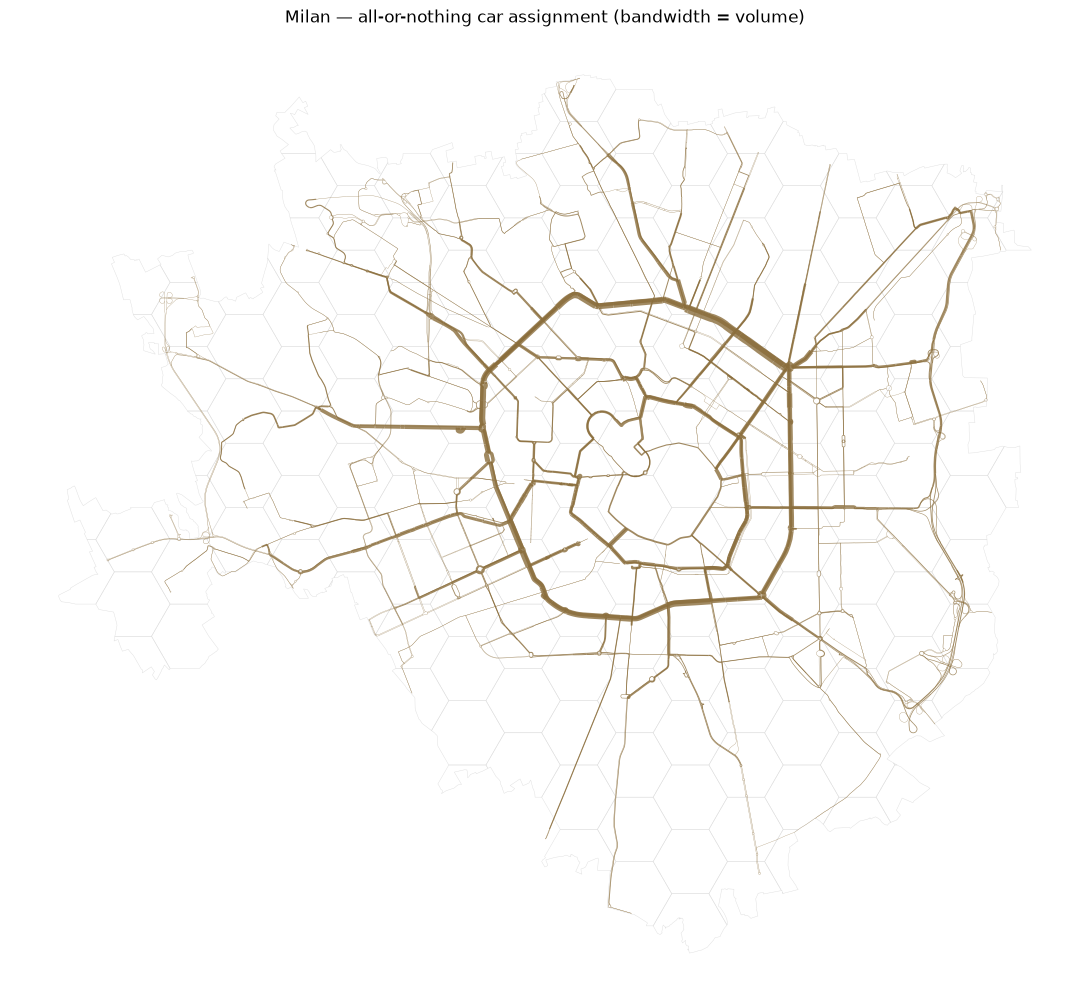

In [15]:
fig, ax = plt.subplots(figsize=(11, 11))
grid.boundary.plot(ax=ax, linewidth=0.3, color="#dddddd")
loaded = edges_gdf.sort_values("flow")
w = 0.2 + 6 * loaded["flow"] / max(loaded["flow"].max(), 1)
loaded.plot(ax=ax, linewidth=w, color="#8a6d3b", alpha=0.8)
ax.set_title("Milan — all-or-nothing car assignment (bandwidth = volume)")
ax.set_axis_off(); plt.tight_layout(); plt.show()

## 11. Select-link analysis

*Who uses this link?* Isolate every OD pair whose shortest path crosses the busiest
motorway link, and map only those flows — the standard tool for judging who a scheme serves.

In [16]:
study = edges_gdf[edges_gdf["cls"] == "motorway"].nlargest(1, "flow")
if study.empty:
    study = edges_gdf.nlargest(1, "flow")
study = study.iloc[0]
sel_link = (int(study["u"]), int(study["v"]))

sel_flow = defaultdict(float)
sel_total = 0.0
for i in tqdm(range(Z), desc="select-link"):
    paths = nx.single_source_dijkstra_path(G_osm, access_nodes[i],
                                           weight="time_min")
    for j in range(Z):
        if i == j or T_car[i, j] < 1e-6:
            continue
        p = paths.get(access_nodes[j])
        if p is None:
            continue
        hops = list(zip(p[:-1], p[1:]))
        if sel_link in hops:
            sel_total += T_car[i, j]
            for uv in hops:
                sel_flow[uv] += T_car[i, j]

edges_gdf["sel_flow"] = [sel_flow.get((u, v), 0.0)
                         for u, v in zip(edges_gdf["u"], edges_gdf["v"])]
print(f"study link carries {study['flow']:,.0f} veh; "
      f"{sel_total / T_car.sum():.1%} of all car trips use it")

select-link:   0%|          | 0/163 [00:00<?, ?it/s]

study link carries 4,074 veh; 2.6% of all car trips use it


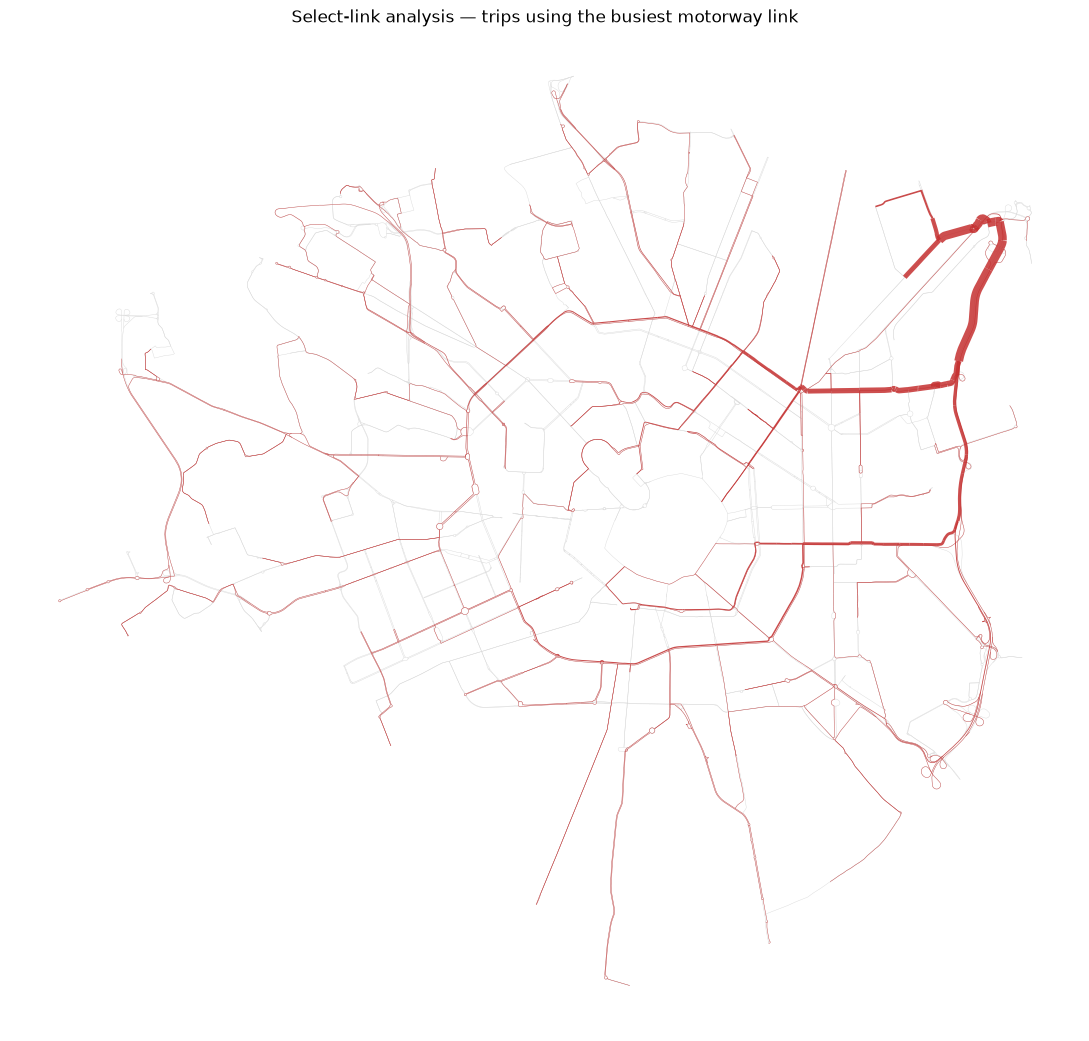

In [17]:
fig, ax = plt.subplots(figsize=(11, 11))
edges_gdf.plot(ax=ax, linewidth=0.3, color="#d9d9d9")
used = edges_gdf[edges_gdf["sel_flow"] > 0].sort_values("sel_flow")
if len(used):
    w = 0.3 + 6 * used["sel_flow"] / used["sel_flow"].max()
    used.plot(ax=ax, linewidth=w, color="#c53030", alpha=0.85)
ax.set_title("Select-link analysis — trips using the busiest motorway link")
ax.set_axis_off(); plt.tight_layout(); plt.show()

## 12. Exports

The skim matrix and the assigned network in hand-off formats a GIS or downstream model
consumes.

In [18]:
from pathlib import Path

out = Path("outputs"); out.mkdir(exist_ok=True)
pd.DataFrame(skim, index=grid["Z"], columns=grid["Z"]).to_csv(
    out / "skim_minutes.csv", float_format="%.2f")
edges_gdf[["u", "v", "cls", "capacity", "flow", "vc_ratio", "geometry"]] \
    .to_crs("EPSG:4326").to_file(out / "assigned_network.geojson",
                                 driver="GeoJSON")
grid[["Z", "population", "jobs", "productions", "attractions", "geometry"]] \
    .to_crs("EPSG:4326").to_file(out / "zones.geojson", driver="GeoJSON")
print("written:", *[p.name for p in out.iterdir()])

written: assigned_network.geojson skim_minutes.csv zones.geojson


## Closing notes — from open-data baseline to production model

**Carries over unchanged** to a real planning network (I have run this workflow on a
~58,000-link metropolitan model with 2030/2040 scenario attributes): graph construction,
skim building, gravity calibration machinery, and the select-link tooling.

**What a production model adds:**

- **Equilibrium assignment** — BPR volume-delay functions iterated to user equilibrium
  (Frank-Wolfe / bi-conjugate) instead of all-or-nothing.
- **Real land use and calibrated parameters** — census population and employment,
  trip rates from surveys, $\beta$ and logit coefficients estimated, matrices validated
  against counts.
- **A transit network** — timetable- or frequency-based PT pathbuilding rather than a
  car-time transformation.
- **Demand segmentation** — purposes, time periods, car ownership.

*Amirhesam Badeanlou — see also my
[routing engine](https://github.com/abadeanlou/routing-engine-osmnx) (live at
[abadeanlou.com/routing-engine](https://abadeanlou.com/routing-engine/)) and
[transit accessibility](https://github.com/abadeanlou/Accessibility-using-Transit)
work ([live maps](https://abadeanlou.com/accessibility/)).*